In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score

# Validation data

In [3]:
models = ['A0201_ELAGIGILTV', 'A0201_GILGFVFTL', 'A0201_LLWNGPMAV', 'A0201_GLCTLVAML']

for model in models:
    df = pd.read_csv(f'../260330_af3_benchmark/Supplementary_Tables/Supplementary_Table_1.csv')[['Epitope', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'dataset_source', 'Label']]
    df = df.rename(columns={'Epitope' : 'model'})
    df = df[df['model'] == model]

    df = df[df['dataset_source'].isin(['Public TCRs with undetermined specificities', 'Public Paired Data'])]


    topdir = model.split('_')[1]
    df.to_csv(f'{topdir}/validation.csv')


# Optimization

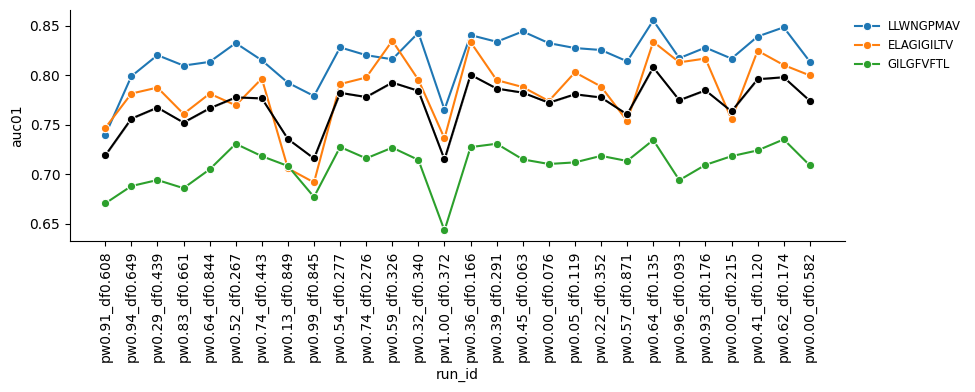

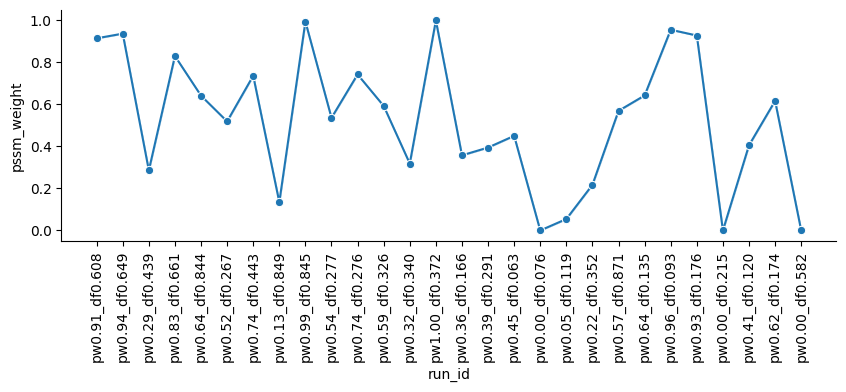

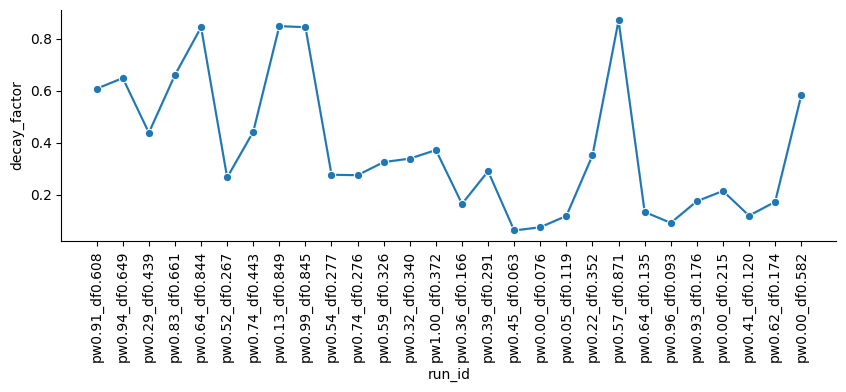

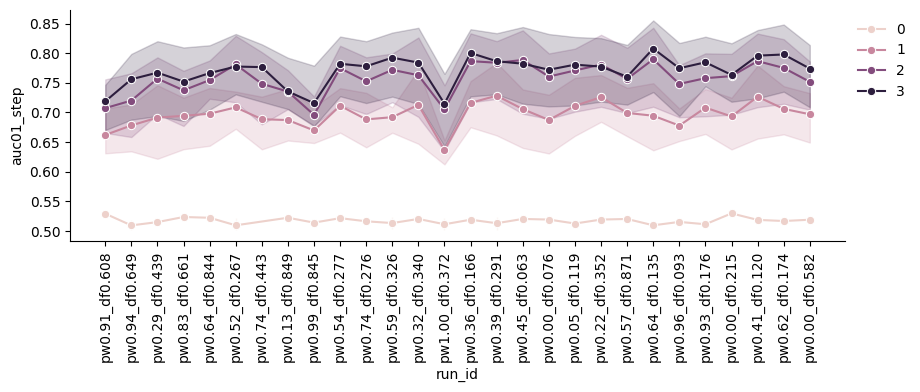

In [16]:
df = pd.read_csv('optimizer_runs/bayes_history.csv')

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='auc01', hue='peptide', ax=ax, marker='o')
sns.lineplot(df, x='run_id', y='mean_auc01', ax=ax, marker='o', color='black')
ax.tick_params(axis='x', rotation=90)

ax.legend(bbox_to_anchor=(1,1), frameon=False, fontsize='small')
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='pssm_weight', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='decay_factor', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

df_long = df.melt(
    id_vars=['run_id', 'pssm_weight', 'decay_factor', 'mean_auc01', 'peptide', 'auc01'],
    value_vars=['auc01_step0', 'auc01_step1', 'auc01_step2', 'auc01_step3'],
    var_name='step',
    value_name='auc01_step'
)

df_long['step'] = df_long['step'].str.replace('auc01_step', '').astype(int)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df_long, x='run_id', y='auc01_step', hue='step', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
ax.legend(bbox_to_anchor=(1,1), frameon=False)
sns.despine()


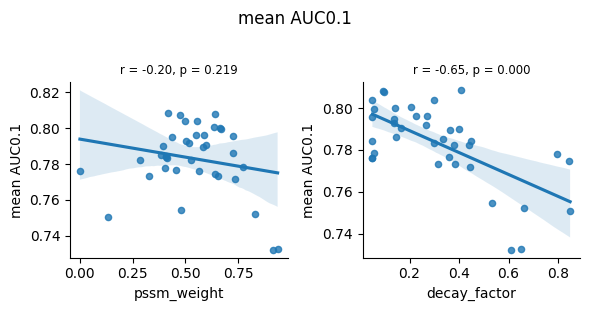

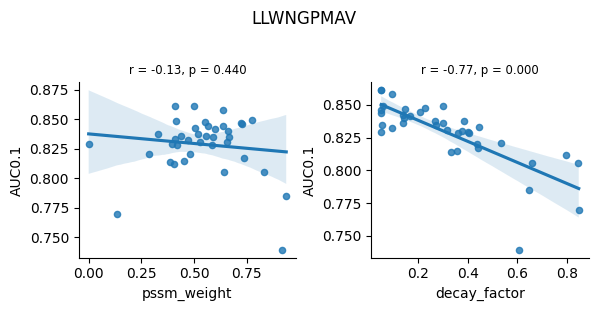

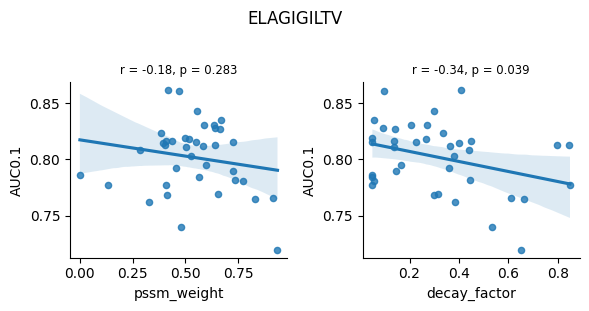

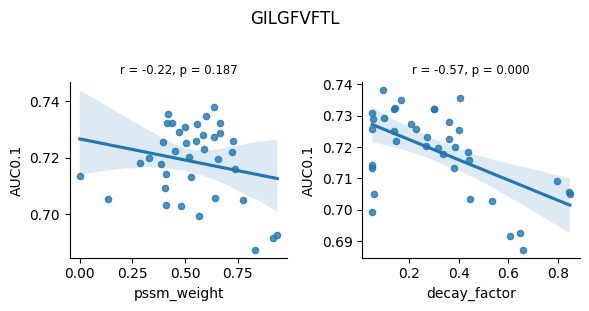

In [40]:
df = pd.read_csv('optimizer_runs/bayes_history.csv')
df = df[df['step'] == 3]

params = ['pssm_weight', 'decay_factor']
peptides = df['peptide'].unique()

# mean auc01 correlations
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, param in zip(axes, params):
    df_corr = df[['mean_auc01', param]].drop_duplicates()
    r, p = stats.pearsonr(df_corr[param], df_corr['mean_auc01'])
    sns.regplot(df_corr, x=param, y='mean_auc01', ax=ax, scatter_kws={'s': 20})
    ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
    ax.set_xlabel(param)
    ax.set_ylabel('mean AUC0.1')
plt.suptitle('mean AUC0.1', y=1.02)
plt.tight_layout()
sns.despine()

# per-peptide correlations
for peptide in peptides:
    df_pep = df[df['peptide'] == peptide]
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, param in zip(axes, params):
        r, p = stats.pearsonr(df_pep[param], df_pep['auc01'])
        sns.regplot(df_pep, x=param, y='auc01', ax=ax, scatter_kws={'s': 20})
        ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
        ax.set_xlabel(param)
        ax.set_ylabel('AUC0.1')
    plt.suptitle(peptide, y=1.02)
    plt.tight_layout()
    sns.despine()

# TEMPO AUC

Training on experimental TCRs (TCR motif atlas)

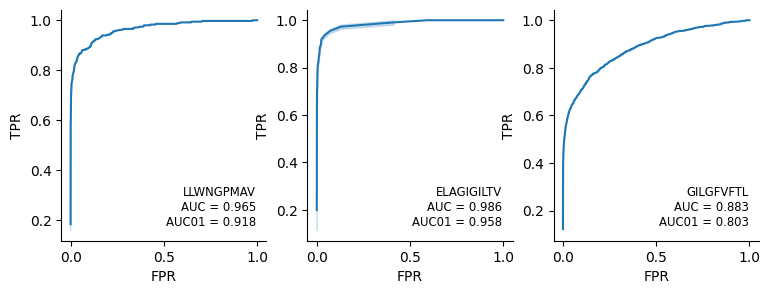

In [17]:
peptides = ['LLWNGPMAV', 'ELAGIGILTV', 'GILGFVFTL']

fig, axes = plt.subplots(1,3,figsize=(9,3))

for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]
    df = pd.read_csv(f'test_TEMPO_validation_{peptide}/validation_pred.csv')

    y_true = df['Label'].values
    y_scores = df['score'].values

    # ROC + metrics
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_full = roc_auc_score(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)  # standardized AUC01

    # plot
    sns.lineplot(x=fpr, y=tpr, ax=ax)

    label = f"{peptide}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"

    ax.text(
        0.95, 0.05,
        label,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize='small'
    )

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    sns.despine()


Training on in silico enriched TCRs

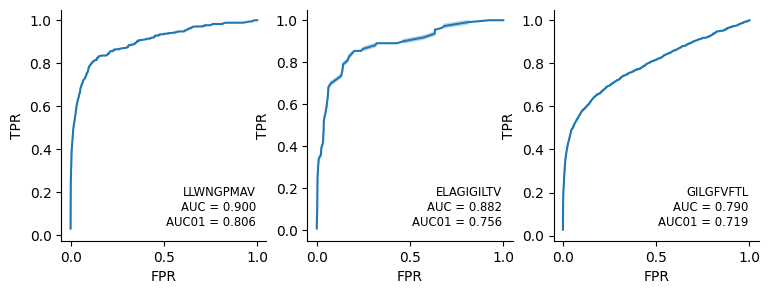

In [37]:
peptides = ['LLWNGPMAV', 'ELAGIGILTV', 'GILGFVFTL']

fig, axes = plt.subplots(1,3,figsize=(9,3))

for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]
    df = pd.read_csv(f'TEMPO_validation_{peptide}/validation_pred.csv')

    y_true = df['Label'].values
    y_scores = df['score'].values

    # ROC + metrics
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_full = roc_auc_score(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)  # standardized AUC01

    # plot
    sns.lineplot(x=fpr, y=tpr, ax=ax)

    label = f"{peptide}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"

    ax.text(
        0.95, 0.05,
        label,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize='small'
    )

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    sns.despine()



# Optimize number of TCRs to score 

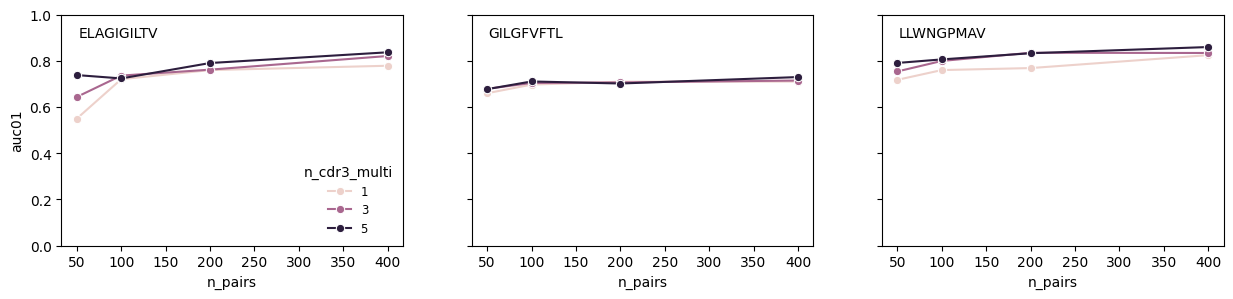

In [23]:
df = pd.read_csv('grid_search_runs/grid_results.csv')
df = df.sort_values(by='auc01', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)

for cnt, (peptide, group) in enumerate(df.groupby('peptide')):
    ax = axes[cnt]
    sns.lineplot(group, x='n_pairs', y='auc01', hue='n_cdr3_multi', ax=ax, marker='o',
                 legend=(cnt == 0))
    ax.text(0.05, 0.95, peptide, transform=ax.transAxes,
            fontsize=10, va='top', ha='left')
    if cnt == 0:
        ax.legend(title='n_cdr3_multi', loc='lower right', frameon=False, fontsize='small')

    ax.set_ylim(0, 1)


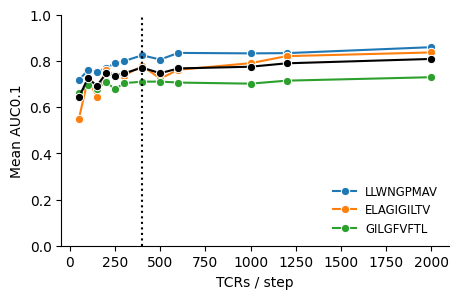

In [36]:
df['tcrs_per_step'] = df['n_pairs'] * df['n_cdr3_multi']
mean_df = df.groupby('tcrs_per_step')['auc01'].mean().reset_index()

fig, ax = plt.subplots(figsize=(5, 3))
sns.lineplot(mean_df, x='tcrs_per_step', y='auc01', marker='o', ax=ax, color='black', zorder=3)
sns.lineplot(df, x='tcrs_per_step', y='auc01', hue='peptide', marker='o', ax=ax)
ax.set_xlabel('TCRs / step')
ax.set_ylabel('Mean AUC0.1')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', frameon=False, fontsize='small')
sns.despine()
ax.axvline(x=400, linestyle=':', color='black')